---
# STEP 7 FPI 구간별 텍스트 분석

## 분석 개요

STEP 6에서 확정된 FPI 구간(NP/LP/HP)별로 독립 브랜드 리뷰 텍스트를 분석하여
경쟁 압력 수준에 따라 소비자가 어떤 언어로 반응하는지 탐색한다.

| 단계 | 내용 |
|---|---|
| STEP 7-1 | 데이터 준비 (리뷰 + FPI 구간 조인) |
| STEP 7-2 | 텍스트 전처리 |
| STEP 7-3 | 구간별 TF-IDF 핵심 키워드 추출 |
| STEP 7-4 | log-odds로 구간별 고유 단어 추출 -> 구간 간 TF-IDF 차이로 구간별 고유 단어 추출|
| STEP 7-5 | 시각화 (워드클라우드, 바차트) |

**입력 데이터**
- `review_target.csv`: 리뷰 텍스트 929,606개
- `biz_indie_with_groups.csv`: 독립 브랜드 FPI 구간 정보

**분석 단위**: 리뷰 단위 (브랜드 단위보다 텍스트 볼륨 풍부)

## 공통 라이브러리 및 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import warnings
warnings.filterwarnings('ignore')

fm._load_fontmanager(try_read_cache=False)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

nltk.download('stopwords', quiet=True)

PATH_to_data = "../results"
PATH_to_save = "../results"

print("라이브러리 로드 완료")

라이브러리 로드 완료


---
## STEP 7-1. 데이터 준비

리뷰 데이터에 FPI 구간 정보를 조인한다.
영업 중인 독립 브랜드(is_open=1)의 리뷰만 사용한다.

In [2]:
# 데이터 로드
review = pd.read_csv(f"{PATH_to_data}/review_target.csv")
indie_groups = pd.read_csv(f"{PATH_to_data}/biz_indie_with_groups.csv")

# 영업 중인 독립 브랜드만 필터링 (STEP 6과 동일 기준)
indie_groups = indie_groups[indie_groups['is_open'] == 1].copy()

print(f"독립 브랜드: {len(indie_groups):,}개")
print(f"전체 리뷰: {len(review):,}개")

# 리뷰에 FPI 구간 조인
review_indie = review.merge(
    indie_groups[['business_id', 'fpi_group', 'fpi_300m']],
    on='business_id', how='inner'
)

print(f"\n조인 후 리뷰 수: {len(review_indie):,}개")
print(f"\nFPI 구간별 리뷰 수:")
print(review_indie['fpi_group'].value_counts())

독립 브랜드: 3,017개
전체 리뷰: 929,606개

조인 후 리뷰 수: 751,890개

FPI 구간별 리뷰 수:
fpi_group
HP    342861
LP    300586
NP    108443
Name: count, dtype: int64


---
## STEP 7-2. 텍스트 전처리

STEP 3과 동일한 전처리 방식을 적용한다.
- 소문자화, 숫자/구두점 제거
- 불용어 제거 (NLTK + 커스텀)
- 어간 추출 (Porter Stemmer)

In [3]:
stop_words = set(stopwords.words('english')) | {"does", "not", "thing"}

MANUAL_STOPWORDS = {
    'al', 'also', 'alway', 'anoth', 'area', 'around', 'ask',
    'back', 'bite', 'box',
    'come', 'could', 'came',
    'dont', 'day', 'de', 'didnt',
    'even', 'ever', 'el',
    'get', 'give', 'got',
    'im', 'ive',
    'let', 'la', 'last',
    'make', 'made', 'mayb',
    'name', 'one', 'round',
    'someth', 'still', 'seem', 'sinc', 'sub', 'said',
    'told', 'that', 'think', 'two', 'though', 'thought', 'took',
    'us', 'want', 'way', 'went', 'would', 'wasnt',
    'your', 'year', 'restaurant', 'place', 'food', 'get',
    'go', 'came', 'got', 'time', 'back', 'order', 'ordered',
}

stemmer = PorterStemmer()

def preprocess(text):
    if pd.isna(text):
        return ''
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [stemmer.stem(w) for w in tokens]
    tokens = [w for w in tokens if w not in MANUAL_STOPWORDS and len(w) > 2]
    return ' '.join(tokens)

print("전처리 함수 정의 완료")
print("전처리 시작 (시간 소요)...")

review_indie['text_clean'] = review_indie['text'].apply(preprocess)

print(f"전처리 완료: {len(review_indie):,}개 리뷰")
print(f"\n샘플 확인:")
print(review_indie[['text', 'text_clean']].head(3))

전처리 함수 정의 완료
전처리 시작 (시간 소요)...
전처리 완료: 751,890개 리뷰

샘플 확인:
                                                text  \
0  We got recommendations for this place from my ...   
1  We stopped in here for lunch this afternoon. S...   
2  I was looking for a nice place to take the fam...   

                                          text_clean  
0  recommend parent anniversari book first first ...  
1  stop lunch afternoon staff help friendli good ...  
2  look nice take famili dinner night read review...  


---
## STEP 7-3. 구간별 TF-IDF 핵심 키워드 추출

FPI 구간별로 리뷰를 합쳐서 하나의 문서로 만들고
TF-IDF로 각 구간의 핵심 키워드를 추출한다.

In [4]:
# 구간별 리뷰 텍스트 합치기
group_texts = {}
for group in ['NP', 'LP', 'HP']:
    texts = review_indie[review_indie['fpi_group'] == group]['text_clean']
    group_texts[group] = ' '.join(texts.dropna().tolist())
    print(f"{group}: {len(texts):,}개 리뷰")

# TF-IDF 계산 (구간을 문서로)
corpus = [group_texts['NP'], group_texts['LP'], group_texts['HP']]

vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=1,
    max_df=1.0,
    ngram_range=(1, 1)
)
tfidf_matrix = vectorizer.fit_transform(corpus)
terms = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=['NP', 'LP', 'HP'],
    columns=terms
)

print(f"\nTF-IDF 행렬: {tfidf_df.shape}")
print("(3개 구간 × 단어 수)")

NP: 108,443개 리뷰
LP: 300,586개 리뷰
HP: 342,861개 리뷰

TF-IDF 행렬: (3, 5000)
(3개 구간 × 단어 수)


In [5]:
# 구간별 상위 키워드 출력
TOP_N = 20

print("=" * 60)
for group in ['NP', 'LP', 'HP']:
    top_words = tfidf_df.loc[group].nlargest(TOP_N)
    print(f"\n[{group}] 상위 {TOP_N}개 키워드:")
    print(top_words.round(4).to_string())
    print()


[NP] 상위 20개 키워드:
good       0.3418
great      0.2363
like       0.2261
servic     0.2143
tri        0.1723
realli     0.1432
restaur    0.1365
vega       0.1339
love       0.1335
best       0.1200
eat        0.1118
wait       0.1096
delici     0.1030
price      0.1026
tast       0.1009
chicken    0.1003
nice       0.0998
well       0.0960
menu       0.0958
fri        0.0920


[LP] 상위 20개 키워드:
good       0.3397
great      0.2376
like       0.2246
servic     0.2218
tri        0.1625
restaur    0.1485
realli     0.1430
vega       0.1400
love       0.1263
eat        0.1179
best       0.1131
wait       0.1067
price      0.1028
delici     0.1017
tast       0.1015
nice       0.0997
menu       0.0982
chicken    0.0982
well       0.0974
tabl       0.0908


[HP] 상위 20개 키워드:
good       0.3397
great      0.2410
like       0.2204
servic     0.2203
tri        0.1561
vega       0.1498
realli     0.1442
restaur    0.1388
love       0.1214
eat        0.1130
chicken    0.1104
best       0.1066
wait    

---
## STEP 7-4. log-odds로 구간별 고유 단어 추출

단순 TF-IDF 상위 키워드는 구간 간 공통 단어가 많이 포함된다.
log-odds를 활용해 특정 구간에서 **다른 구간 대비 고유하게 많이 쓰이는 단어**를 추출한다.

$$\text{log-odds}(w, A) = \log\frac{p(w|A)}{p(w|\bar{A})}$$

- $p(w|A)$: 구간 A에서의 단어 비율
- $p(w|\bar{A})$: 나머지 구간에서의 단어 비율

In [6]:
def compute_log_odds(target_group, other_groups, review_df, top_n=20):
    target_text = ' '.join(
        review_df[review_df['fpi_group'] == target_group]['text_clean'].dropna()
    ).split()
    other_text = ' '.join(
        review_df[review_df['fpi_group'].isin(other_groups)]['text_clean'].dropna()
    ).split()

    target_freq = pd.Series(target_text).value_counts()
    other_freq  = pd.Series(other_text).value_counts()

    all_words = set(target_freq.index) | set(other_freq.index)

    log_odds = {}
    for word in all_words:
        p_target = (target_freq.get(word, 0) + 1) / (len(target_text) + len(all_words))
        p_other  = (other_freq.get(word, 0) + 1)  / (len(other_text)  + len(all_words))
        log_odds[word] = np.log(p_target / p_other)

    log_odds_series = pd.Series(log_odds).sort_values(ascending=False)

    # 길이 2 이하 단어 제거
    log_odds_series = log_odds_series[log_odds_series.index.str.len() > 2]

    return log_odds_series.head(top_n)


print("구간별 고유 키워드 (log-odds 기준)")
print("=" * 60)

for group in ['NP', 'LP', 'HP']:
    others = [g for g in ['NP', 'LP', 'HP'] if g != group]
    top = compute_log_odds(group, others, review_indie, top_n=20)
    print(f"\n[{group}] 고유 키워드 상위 20개:")
    print(top.round(4).to_string())

구간별 고유 키워드 (log-odds 기준)

[NP] 고유 키워드 상위 20개:
boyger        6.6231
chencho       6.4172
porko         5.8408
olivi         5.7670
mingo         5.4930
bagelmania    5.4768
manan         5.4646
oggi          5.4522
reubenish     5.4268
cobrinha      5.4009
benicio       5.3468
benecio       5.2896
mayakovski    5.2598
saipin        5.2598
bundtini      5.2290
arawan        5.1719
plar          5.1645
rosu          5.1645
rebar         5.1645
bundtlet      5.1306

[LP] 고유 키워드 상위 20개:
frangria      5.0743
mcclain       4.8695
komex         4.8663
taiyaki       4.8638
mto           4.7532
illumilatt    4.7097
latti         4.6963
koro          4.6827
bingsoo       4.6689
bacio         4.5969
phrank        4.5234
eatt          4.5193
rrl           4.4697
garlicch      4.3995
bltae         4.3625
mixx          4.3625
biaggio       4.3338
tashja        4.3240
firerock      4.3042
cheffini      4.2423

[HP] 고유 키워드 상위 20개:
lobsicl      5.3586
kelaguen     5.0098
casanova     5.0098
chamorro    

### STEP 7-4 수정: 고유명사 필터링

기존 log-odds 결과에서 브랜드명, 고유명사 등 희귀 단어가 상위에 올라오는 문제가 발생했다.
전체 리뷰에서 최소 500회 이상 등장한 단어만 대상으로 log-odds를 계산하여 의미있는 키워드를 추출한다.

In [13]:
MIN_COUNT = 500  # 100 → 500으로 올리기

# 추가 필터: 알파벳만, 길이 3 이상
valid_words = set(
    word for word, cnt in word_freq.items()
    if cnt >= MIN_COUNT
    and word.isalpha()
    and len(word) >= 3
)

print(f"전체 단어 수: {len(word_freq):,}개")
print(f"500회 이상 + 알파벳만 단어 수: {len(valid_words):,}개")
print(f"\n유효 단어 샘플 (상위 30개):")
print(word_freq[word_freq.index.isin(valid_words)].head(30))

전체 단어 수: 298,603개
500회 이상 + 알파벳만 단어 수: 4,236개

유효 단어 샘플 (상위 30개):
good       500351
great      351652
like       327981
servic     323842
tri        236867
vega       211345
realli     211302
restaur    209497
love       184019
eat        168973
best       163561
wait       156793
chicken    153116
price      150006
delici     147629
nice       147254
tast       146587
well       142453
fri        141895
menu       141338
tabl       133392
drink      129537
definit    128582
amaz       124105
look       123631
flavor     119834
littl      119151
dish       117107
first      112409
much       112179
Name: count, dtype: int64


In [14]:
# valid_words 업데이트 후 log-odds 재계산
print("구간별 고유 키워드 (log-odds, 500회 이상 + 알파벳 필터)")
print("=" * 60)

log_odds_results = {}
for group in ['NP', 'LP', 'HP']:
    others = [g for g in ['NP', 'LP', 'HP'] if g != group]
    top = compute_log_odds_filtered(group, others, review_indie, valid_words, top_n=20)
    log_odds_results[group] = top
    print(f"\n[{group}] 고유 키워드 상위 20개:")
    print(top.round(4).to_string())

구간별 고유 키워드 (log-odds, 500회 이상 + 알파벳 필터)

[NP] 고유 키워드 상위 20개:
freed        4.6837
jjanga       3.9141
rig          3.7222
grouchi      3.5291
tivoli       3.5067
lawri        3.4697
pasti        3.3531
siam         2.8803
golf         2.8581
lotu         2.6154
echo         2.6039
lola         2.5097
nam          2.3135
northern     2.2215
sinatra      2.0674
skinnyfat    2.0178
harvest      1.9952
bagel        1.9732
barrel       1.9159
sunris       1.9096

[LP] 고유 키워드 상위 20개:
komex        4.8727
raku         3.3418
barrymor     3.3041
ichiza       3.2101
scarpetta    2.8527
kabuto       2.7240
gabi         2.7220
nora         2.7111
holstein     2.7085
samba        2.7012
carson       2.5419
wong         2.5044
izakaya      2.3429
jun          2.3309
elli         2.3177
yakitori     2.0755
rollin       2.0663
yama         2.0232
soju         1.9986
javier       1.9901

[HP] 고유 키워드 상위 20개:
montagu         4.4372
giada           4.1476
yardbird        3.9901
lavo            3.8255
hakka

### STEP 7-4 수정: 구간 간 TF-IDF 차이로 접근 방식 변경

구간별 고유 키워드를 뽑으려면 log-odds보다 구간 간 TF-IDF 차이를 보는 게 더 적합하다.

In [15]:
# 구간별 TF-IDF 차이로 고유 키워드 추출
# HP에서 높고 NP에서 낮은 단어 = HP 고유 키워드
for group, others in [('NP', ['LP', 'HP']),
                       ('LP', ['NP', 'HP']),
                       ('HP', ['NP', 'LP'])]:
    
    target_score = tfidf_df.loc[group]
    other_score  = tfidf_df.loc[others].mean()
    
    # 차이값 계산
    diff = (target_score - other_score).sort_values(ascending=False)
    
    # valid_words 필터 적용
    diff = diff[diff.index.isin(valid_words)]
    
    print(f"\n[{group}] 고유 키워드 상위 20개 (TF-IDF 차이):")
    print(diff.head(20).round(4).to_string())


[NP] 고유 키워드 상위 20개 (TF-IDF 차이):
thai        0.0399
coffe       0.0352
pho         0.0338
buffet      0.0317
cake        0.0206
wynn        0.0186
noodl       0.0171
bellagio    0.0147
sandwich    0.0136
tri         0.0130
rib         0.0127
cafe        0.0120
rice        0.0114
prime       0.0113
soup        0.0107
curri       0.0106
best        0.0101
pad         0.0101
bagel       0.0101
sum         0.0099

[LP] 고유 키워드 상위 20개 (TF-IDF 차이):
pizza       0.0228
steak       0.0205
sushi       0.0165
ramen       0.0137
restaur     0.0109
korean      0.0078
dish        0.0078
roll        0.0073
donut       0.0071
cook        0.0068
oyster      0.0066
rice        0.0065
fountain    0.0064
japanes     0.0063
server      0.0060
downtown    0.0057
slice       0.0056
sauc        0.0056
eat         0.0055
pan         0.0055

[HP] 고유 키워드 상위 20개 (TF-IDF 차이):
burger      0.0431
drink       0.0184
chees       0.0162
sandwich    0.0147
vega        0.0129
bread       0.0129
fri         0.0127
lobster 

---
## STEP 7-5. 시각화

### 7-5-1. 구간별 워드클라우드

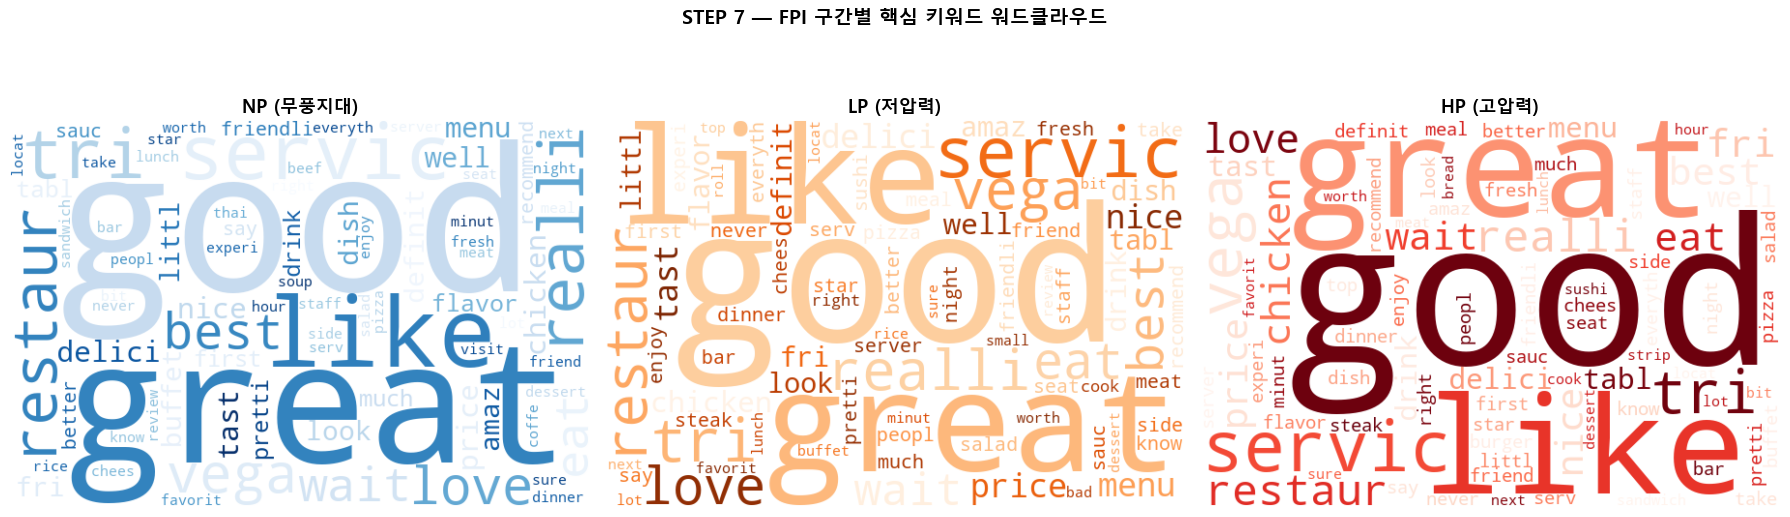

저장 완료: step7_wordcloud.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('STEP 7 — FPI 구간별 핵심 키워드 워드클라우드',
             fontsize=14, fontweight='bold')

colors = {'NP': 'Blues', 'LP': 'Oranges', 'HP': 'Reds'}
titles = {'NP': 'NP (무풍지대)', 'LP': 'LP (저압력)', 'HP': 'HP (고압력)'}

for ax, group in zip(axes, ['NP', 'LP', 'HP']):
    freq_dict = tfidf_df.loc[group].nlargest(100).to_dict()
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap=colors[group],
        max_words=80
    ).generate_from_frequencies(freq_dict)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(titles[group], fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step7_wordcloud.png", dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: step7_wordcloud.png")

### 7-5-2 : 구간 간 TF-IDF 차이 시각화

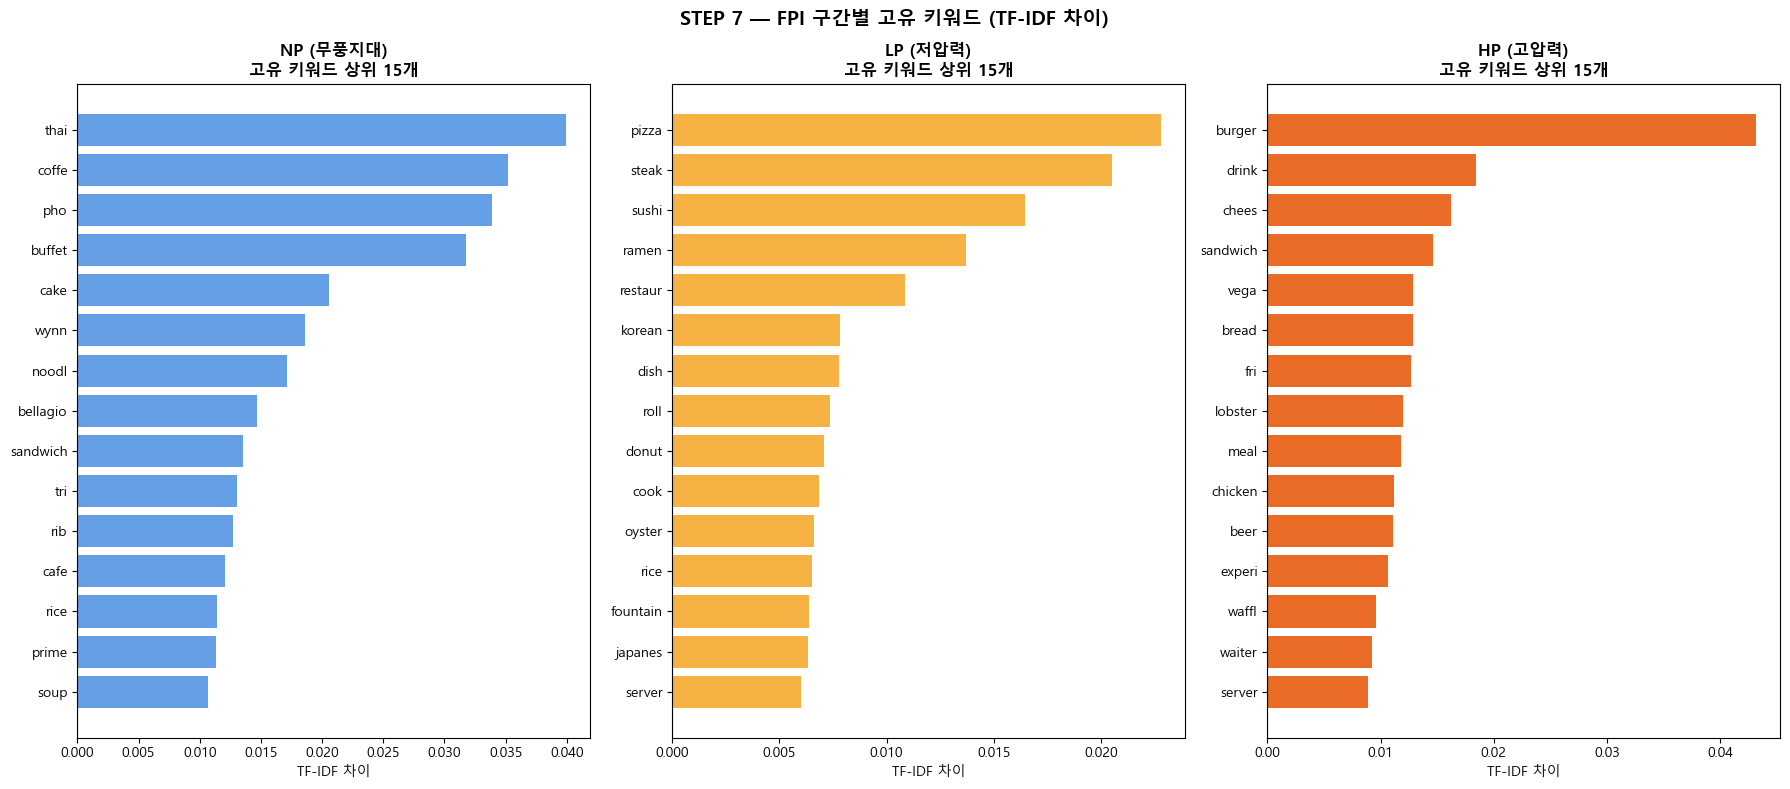

저장 완료: step7_tfidf_diff.png


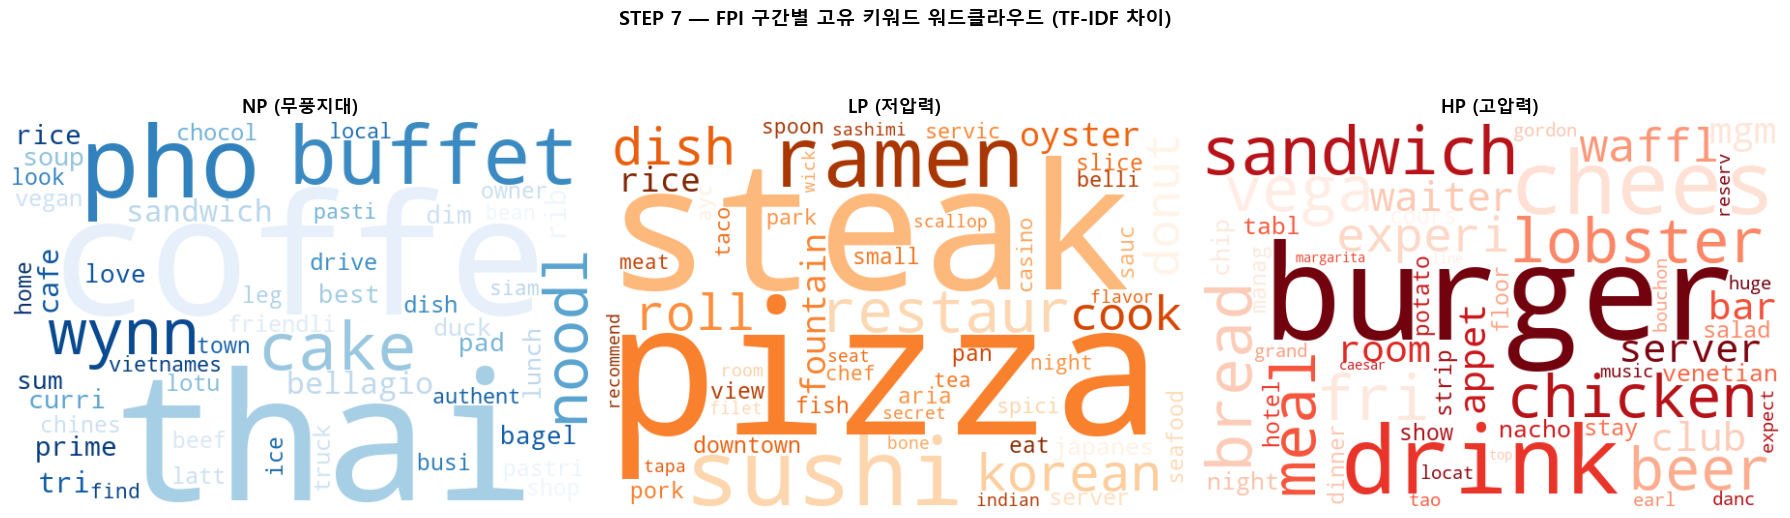

저장 완료: step7_tfidf_wordcloud.png


In [16]:
# TF-IDF 차이 기반 고유 키워드 저장
tfidf_diff_results = {}
for group, others in [('NP', ['LP', 'HP']),
                       ('LP', ['NP', 'HP']),
                       ('HP', ['NP', 'LP'])]:
    target_score = tfidf_df.loc[group]
    other_score  = tfidf_df.loc[others].mean()
    diff = (target_score - other_score).sort_values(ascending=False)
    diff = diff[diff.index.isin(valid_words)]
    tfidf_diff_results[group] = diff

# 바차트
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
fig.suptitle('STEP 7 — FPI 구간별 고유 키워드 (TF-IDF 차이)',
             fontsize=14, fontweight='bold')

bar_colors = {'NP': '#4a90e2', 'LP': '#f5a623', 'HP': '#e65100'}
titles = {'NP': 'NP (무풍지대)', 'LP': 'LP (저압력)', 'HP': 'HP (고압력)'}

for ax, group in zip(axes, ['NP', 'LP', 'HP']):
    top = tfidf_diff_results[group].head(15)
    ax.barh(top.index[::-1], top.values[::-1],
            color=bar_colors[group], alpha=0.85)
    ax.set_title(f'{titles[group]}\n고유 키워드 상위 15개',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('TF-IDF 차이')
    ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step7_tfidf_diff.png", dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: step7_tfidf_diff.png")

# 워드클라우드
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('STEP 7 — FPI 구간별 고유 키워드 워드클라우드 (TF-IDF 차이)',
             fontsize=14, fontweight='bold')

wc_colors = {'NP': 'Blues', 'LP': 'Oranges', 'HP': 'Reds'}

for ax, group in zip(axes, ['NP', 'LP', 'HP']):
    top = tfidf_diff_results[group].head(50)
    freq_dict = {word: score for word, score in top.items() if score > 0}
    if freq_dict:
        wc = WordCloud(
            width=600, height=400,
            background_color='white',
            colormap=wc_colors[group],
            max_words=50
        ).generate_from_frequencies(freq_dict)
        ax.imshow(wc, interpolation='bilinear')
    ax.set_title(titles[group], fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step7_tfidf_wordcloud.png", dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: step7_tfidf_wordcloud.png")

---
## STEP 7 결과 정리

### 분석 방법 최종 채택
- 초기 log-odds 방식은 고유명사(식당명, 지명) 필터링 한계로 TF-IDF 차이 방식으로 변경
- 전체 리뷰에서 500회 이상 등장한 알파벳 단어만 유효 단어로 사용 (4,236개)

---

### FPI 구간별 리뷰 볼륨

| 구간 | 리뷰 수 |
|---|---|
| NP (무풍지대) | 108,443개 |
| LP (저압력) | 300,586개 |
| HP (고압력) | 342,861개 |

---

### 구간별 고유 키워드 (TF-IDF 차이 기준)

**NP (무풍지대)** — thai, coffee, pho, buffet, cake, noodle, sandwich, rice, curry, soup
> 특정 음식 전문 카테고리 키워드가 두드러진다.
> 프랜차이즈 경쟁이 없는 조용한 상권에서 **태국 음식, 베트남 음식, 카페, 뷔페 등
> 특색있는 전문점**이 강세를 보이는 패턴이다.

**LP (저압력)** — pizza, steak, sushi, ramen, korean, roll, oyster, japanese, donut
> **정통 요리 카테고리** 키워드가 중심이다.
> 프랜차이즈가 일부 존재하는 지역에서 스시, 라멘, 한식, 스테이크 등
> 특색있는 외국 요리 독립 식당들이 경쟁하는 패턴이다.

**HP (고압력)** — burger, drink, cheese, sandwich, bread, fries, lobster, beer, waiter, server, experience
> 캐주얼 다이닝 메뉴 + 서비스 관련 단어(waiter, server, experience)가 함께 등장한다.
> 프랜차이즈 밀집 지역에서 독립 브랜드가 유사한 메뉴(버거, 샌드위치)로 경쟁하면서,
> 서비스 품질과 경험을 차별화 요소로 내세우는 패턴이다.

---

### 핵심 인사이트

| 구간 | 차별화 전략 | 대표 키워드 |
|---|---|---|
| NP (무풍지대) | 특색 음식 전문점 (에스닉 요리) | thai, pho, buffet, noodle |
| LP (저압력) | 정통 외국 요리 전문성 | pizza, sushi, ramen, steak |
| HP (고압력) | 서비스·경험 차별화 | waiter, server, experience, meal |

> FPI가 높아질수록 독립 브랜드의 메뉴가 프랜차이즈와 유사해지는 경향이 나타난다.
> 반면 경쟁 압력이 낮은 구간에서는 특색있는 에스닉 요리나 전문 요리로 차별화하는 전략이 두드러진다.
> 이는 **고압력 환경의 독립 브랜드가 메뉴 차별화보다 서비스 품질로 경쟁하는 전략**을 취함을 시사한다.

---

> 다음 단계(STEP 8)에서는 고압력 구간 내에서도 높은 별점을 유지하는
> '생존 브랜드'의 언어적 특징을 분석하여 구체적인 차별화 전략을 도출한다.

---
## 7-6 

흐름:
1. 브랜드별 리뷰 텍스트 합치기
2. valid_words 필터 적용해서 브랜드별 TF-IDF 계산 -> 이거 step3에서 만들어 둔 거 사용?
3. PCA (브랜드 수 × 단어 수 → 2D)
4. 각 브랜드를 FPI 구간 색깔로 scatter
5. loading 화살표는 구간별 고유 키워드만 선택해서 표시
   (thai, pho, coffee → NP 방향
    pizza, sushi, ramen → LP 방향
    burger, waiter, server → HP 방향)